# NB3: Psychometrics as Predictors
- **Question:** Do Big Five personality traits and non-verbal IQ predict annotation accuracy and reliance on AI?
- **Primary GT:** Platinum Consensus
- **KL1 Strategy:** Exclude (Strategy A)
- **Hypothesis:** Higher neuroticism predicts higher over-reliance on AI feedback, and baseline accuracy is modulated by IQ and conscientiousness.
- **Data Note:** The analysis is strictly performed on the **N=51 completer cohort**. Dropouts who did not complete the full study are excluded to ensure data integrity.
- **Data Note:** This notebook uses the finalized **N=51 completer cohort**. All non-completers are excluded.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy import stats
from statsmodels.stats.multitest import multipletests
import pingouin as pg
import warnings
import sys, os; sys.path.append(os.path.abspath(".")); import helpers

warnings.filterwarnings("ignore")

    # 1. Load Data (Strictly N=51 completers)
df = helpers.load_data("exclude", filter_completers=True, filter_psychometrics=True)
df["human_correct_plat_int"] = df["human_correct_plat"].astype(int)
df["over_reliance_int"] = df["over_reliance"].astype(int)
df["human_correct_orig_int"] = df["human_correct_plat"].astype(int)

df_part = helpers.participant_summary(df)
df_img = helpers.image_summary(df)

b5_cols = ["big5_open_mindedness", "big5_conscientiousness", "big5_extraversion", "big5_agreeableness", "big5_neuroticism", "iq_score"]
facet_cols = [c for c in df_part.columns if c.startswith("facet_")]

print(f"Setup Complete. N={len(df_part)} participants loaded.")


Data Loading (Old GT Only Mode): 51 participants selected (from 68 initial).
Setup Complete. N=51 participants loaded.


## Section 1: Descriptive Psychometrics

--- Descriptive Psychometrics ---
       big5_open_mindedness  big5_conscientiousness  big5_extraversion  \
count             51.000000               51.000000          51.000000   
mean               3.774118                3.383725           3.413529   
std                0.627905                0.721642           0.704681   
min                2.500000                1.920000           2.080000   
25%                3.330000                2.830000           2.835000   
50%                3.670000                3.330000           3.500000   
75%                4.210000                4.040000           3.920000   
max                4.920000                4.500000           5.000000   

       big5_agreeableness  big5_neuroticism   iq_score  
count           51.000000         51.000000  51.000000  
mean             3.653725          2.979412   1.117647  
std              0.512144          0.801105   1.632753  
min              2.580000          1.420000   0.000000  
25%           

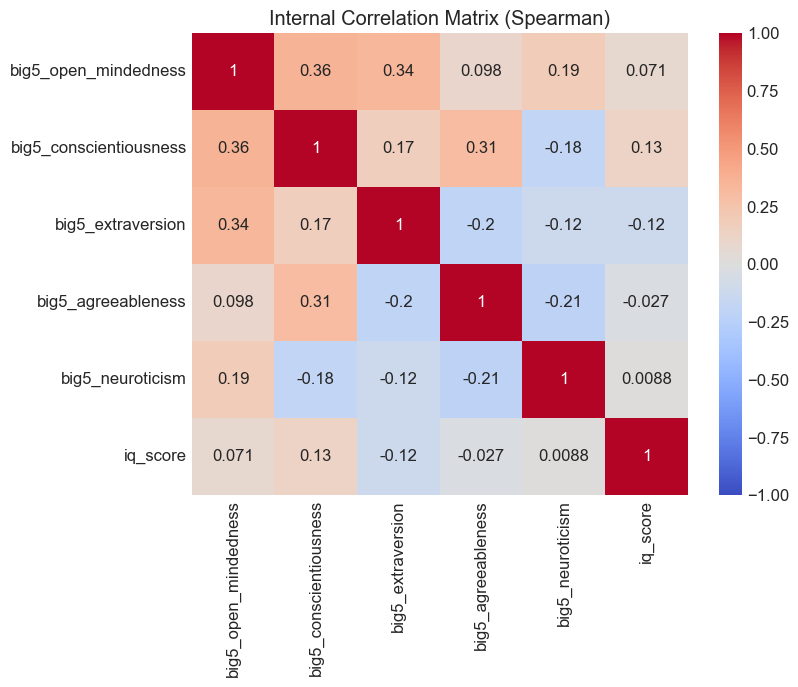


Variance Inflation Factors (VIF > 5 indicates concern):
                 Variable         VIF
0                   const  141.316294
1    big5_open_mindedness    1.468194
2  big5_conscientiousness    1.349282
3       big5_extraversion    1.366464
4      big5_agreeableness    1.254144
5        big5_neuroticism    1.258709
6                iq_score    1.065864


In [2]:
print("--- Descriptive Psychometrics ---")
print(df_part[b5_cols].describe())

corr = df_part[b5_cols].corr(method='spearman')
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title("Internal Correlation Matrix (Spearman)")
plt.show()

# VIF for multicollinearity
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = sm.add_constant(df_part[b5_cols].dropna())
vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print("\nVariance Inflation Factors (VIF > 5 indicates concern):")
print(vif)


## Section 2: Psychometrics and Accuracy

In [3]:
print("--- Spearman Correlations (FDR Corrected) ---")
res = []
for cond in ['ai', 'no_ai']:
    acc_col = 'accuracy_ai_condition' if cond == 'ai' else 'accuracy_noai_condition'
    for c in b5_cols:
        r, p = stats.spearmanr(df_part[c], df_part[acc_col], nan_policy='omit')
        res.append({'Condition': cond, 'Trait': c, 'r': r, 'p_raw': p})

res_df = pd.DataFrame(res)
res_df['p_fdr'] = multipletests(res_df['p_raw'], method='fdr_bh')[1]
print(res_df.sort_values(['Condition', 'p_fdr']))

print("\n--- GEE Model: Accuracy ~ Psychometrics + Condition ---")
# Using GEE instead of OLS to properly account for repeated trials
formula = "human_correct_plat_int ~ iq_score + big5_neuroticism + big5_conscientiousness + big5_open_mindedness + C(condition)"
m_acc = smf.gee(formula, groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()
print(m_acc.summary().tables[1])


--- Spearman Correlations (FDR Corrected) ---
   Condition                   Trait         r     p_raw     p_fdr
2         ai       big5_extraversion -0.516408  0.000105  0.001258
0         ai    big5_open_mindedness -0.132947  0.352355  0.745699
1         ai  big5_conscientiousness  0.163732  0.250944  0.745699
3         ai      big5_agreeableness  0.047661  0.739798  0.745699
4         ai        big5_neuroticism -0.185311  0.192955  0.745699
5         ai                iq_score  0.070979  0.620634  0.745699
6      no_ai    big5_open_mindedness  0.069106  0.629906  0.745699
7      no_ai  big5_conscientiousness  0.103968  0.467812  0.745699
8      no_ai       big5_extraversion  0.046542  0.745699  0.745699
9      no_ai      big5_agreeableness -0.125029  0.382017  0.745699
10     no_ai        big5_neuroticism -0.170688  0.231093  0.745699
11     no_ai                iq_score -0.068782  0.631518  0.745699

--- GEE Model: Accuracy ~ Psychometrics + Condition ---
                          

## Section 3: Psychometrics and Reliance Behavior

In [4]:
print("--- Reliance Behavior Predictors ---")
rel_res = []
for c in b5_cols:
    r, p = stats.spearmanr(df_part[c], df_part['over_reliance_rate'], nan_policy='omit')
    rel_res.append({'Trait': c, 'Outcome': 'over_reliance', 'r': r, 'p_raw': p})
    
    r2, p2 = stats.spearmanr(df_part[c], df_part['appropriate_skepticism_rate'], nan_policy='omit')
    rel_res.append({'Trait': c, 'Outcome': 'approp_skepticism', 'r': r2, 'p_raw': p2})

rel_df = pd.DataFrame(rel_res)
rel_df['p_fdr'] = multipletests(rel_df['p_raw'], method='fdr_bh')[1]
print(rel_df[rel_df['Outcome'] == 'over_reliance'].sort_values('p_fdr'))

print("\n--- GEE Model: Over-Reliance ~ Psychometrics ---")
# Limit to AI condition since over_reliance only happens there
ai_df = df[df['condition'] == 'ai']
formula_rel = "over_reliance_int ~ iq_score + big5_neuroticism"
m_rel = smf.gee(formula_rel, groups=ai_df["participant_id"], data=ai_df, family=sm.families.Binomial()).fit()
print(m_rel.summary().tables[1])

# Directional test for Neuroticism (one-sided)
p_neu = m_rel.pvalues['big5_neuroticism'] / 2 if m_rel.params['big5_neuroticism'] > 0 else 1 - (m_rel.pvalues['big5_neuroticism'] / 2)
print(f"\nOne-sided p-value for Neuroticism predicting higher Over-Reliance: p = {p_neu:.4f}")


--- Reliance Behavior Predictors ---
                     Trait        Outcome         r     p_raw     p_fdr
2   big5_conscientiousness  over_reliance -0.175229  0.218734  0.441361
4        big5_extraversion  over_reliance  0.174502  0.220680  0.441361
8         big5_neuroticism  over_reliance -0.218160  0.124063  0.441361
0     big5_open_mindedness  over_reliance -0.145794  0.307335  0.461002
6       big5_agreeableness  over_reliance -0.104309  0.466344  0.546083
10                iq_score  over_reliance  0.086512  0.546083  0.546083

--- GEE Model: Over-Reliance ~ Psychometrics ---
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -1.4351      0.137    -10.462      0.000      -1.704      -1.166
iq_score            -0.0088      0.028     -0.319      0.750      -0.063       0.045
big5_neuroticism    -0.0830      0.045     -1.846      0.065      -0.

## Section 4: Facet-level Analysis

--- Facet-Level Exploratory Analysis ---


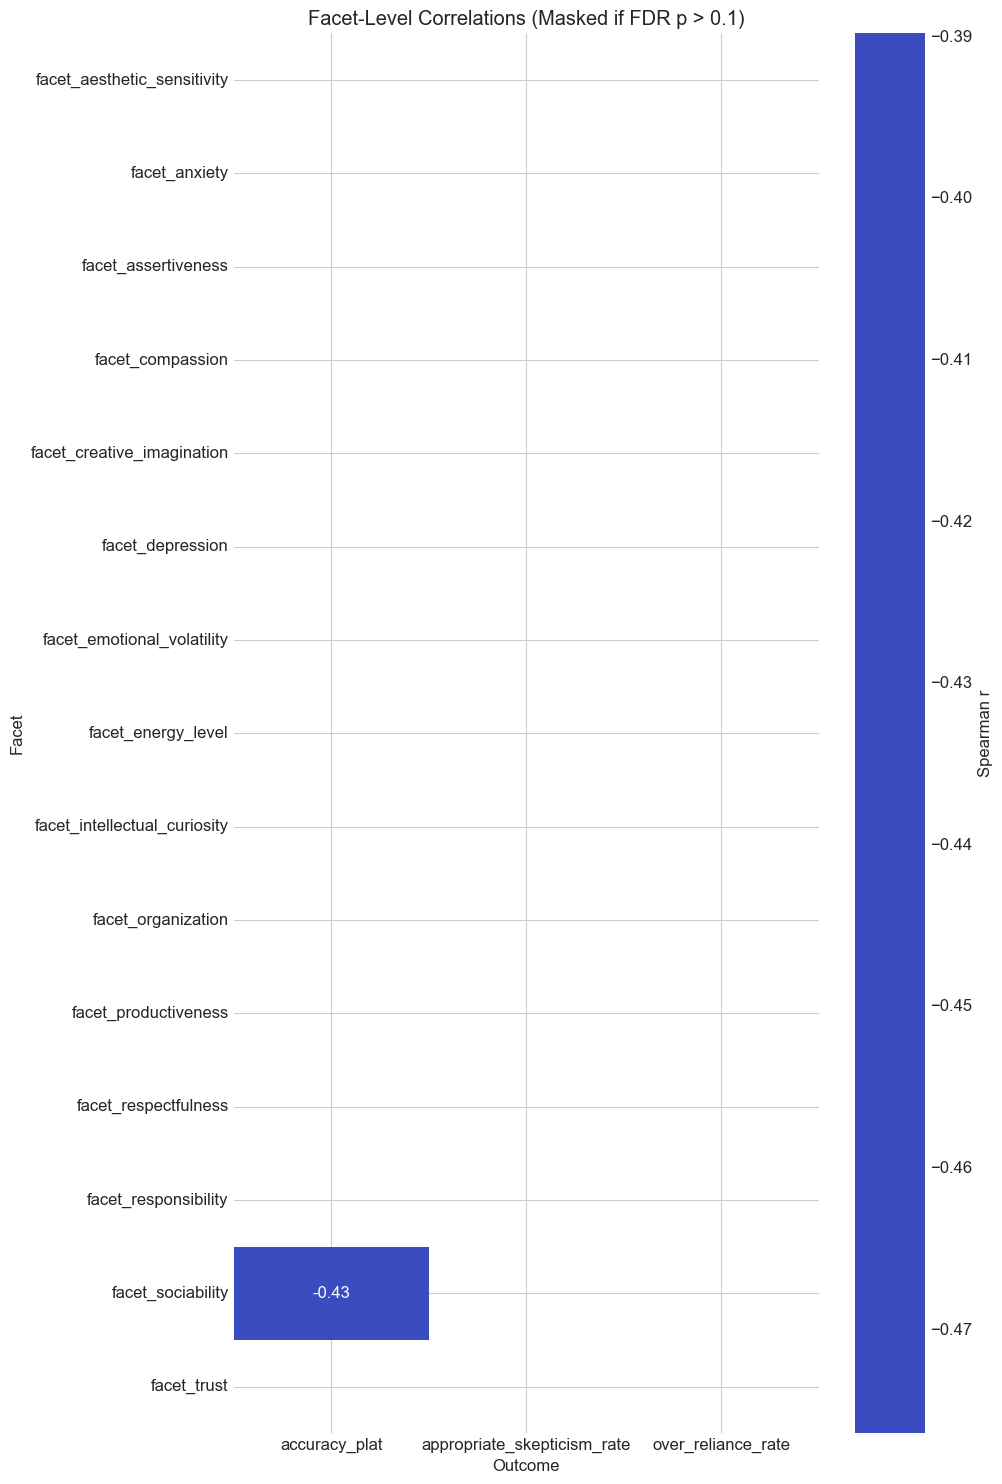

In [5]:
print("--- Facet-Level Exploratory Analysis ---")
if len(facet_cols) == 0:
    print("No facet columns found.")
else:
    f_res = []
    outcomes = ['accuracy_plat', 'over_reliance_rate', 'appropriate_skepticism_rate']
    for out in outcomes:
        for f in facet_cols:
            r, p = stats.spearmanr(df_part[f], df_part[out], nan_policy='omit')
            f_res.append({'Facet': f, 'Outcome': out, 'r': r, 'p_raw': p})
    
    f_df = pd.DataFrame(f_res)
    f_df['p_fdr'] = multipletests(f_df['p_raw'], method='fdr_bh')[1]
    
    # Heatmap of facets vs outcomes (colored by r, but only showing if FDR significant, or masking)
    pivot_r = f_df.pivot(index='Facet', columns='Outcome', values='r')
    pivot_p = f_df.pivot(index='Facet', columns='Outcome', values='p_fdr')
    
    # Mask non-significant correlations
    mask = pivot_p > 0.1 # Using 0.1 for exploratory visibility
    
    plt.figure(figsize=(10, 15))
    sns.heatmap(pivot_r, mask=mask, annot=True, cmap='coolwarm', center=0, cbar_kws={'label': 'Spearman r'})
    plt.title("Facet-Level Correlations (Masked if FDR p > 0.1)")
    plt.tight_layout()
    plt.show()


## Section 5: Robustness Under GT Switch

In [6]:
print("--- GT Switch Robustness ---")
m_acc_orig = smf.gee("human_correct_orig_int ~ iq_score + big5_neuroticism + big5_conscientiousness + big5_open_mindedness + C(condition)", 
                     groups=df["participant_id"], data=df, family=sm.families.Binomial()).fit()

comp_df = pd.DataFrame({
    'Platinum (OR)': np.exp(m_acc.params),
    'Platinum (p)': m_acc.pvalues,
    'Original (OR)': np.exp(m_acc_orig.params),
    'Original (p)': m_acc_orig.pvalues
})

print(comp_df.round(3))


--- GT Switch Robustness ---
                        Platinum (OR)  Platinum (p)  Original (OR)  \
Intercept                       1.944         0.020          1.944   
C(condition)[T.no_ai]           0.812         0.002          0.812   
iq_score                        1.000         0.984          1.000   
big5_neuroticism                0.954         0.339          0.954   
big5_conscientiousness          1.082         0.109          1.082   
big5_open_mindedness            0.959         0.548          0.959   

                        Original (p)  
Intercept                      0.020  
C(condition)[T.no_ai]          0.002  
iq_score                       0.984  
big5_neuroticism               0.339  
big5_conscientiousness         0.109  
big5_open_mindedness           0.548  
